# Handwritten Digit Recognition with Neural Networks

## Overview
A deep learning project that classifies handwritten digits (0-9) using a fully connected neural network on the MNIST dataset.

Technologies Used: Python, Keras/TensorFlow, NumPy, Matplotlib, Scikit-learn

In [24]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import keras
from keras.layers import Dense, Dropout
from keras.models import Sequential
from sklearn.metrics import confusion_matrix
import seaborn as sns

np.random.seed(0)

Data

In [25]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [26]:
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


## 📊 Dataset Information
The MNIST dataset contains:
- **60,000 training images** of handwritten digits (0-9)
- **10,000 test images** for evaluation
- Each image is **28×28 pixels** in grayscale
- **Goal**: Build a neural network to classify digits with high accuracy

Vizualize Examples

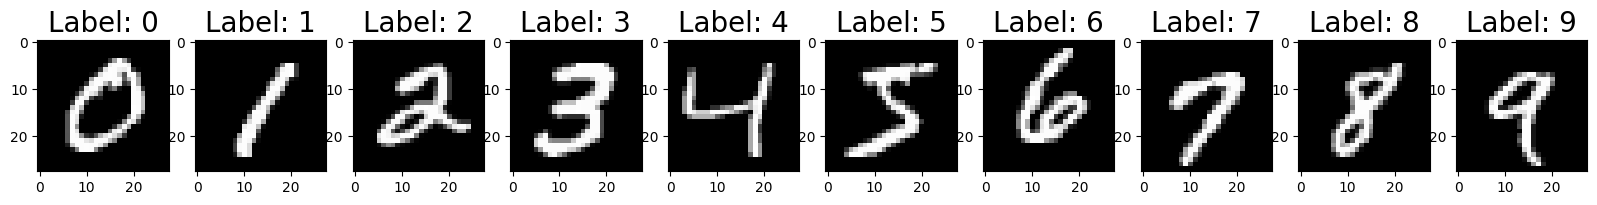

In [44]:
# Load original data for visualization (before preprocessing)
from keras.datasets import mnist
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = mnist.load_data()

num_classes = 10 
f, ax = plt.subplots(1,num_classes, figsize=(20,10))

for i in range(num_classes):
    sample = X_train_orig[y_train_orig == i][0]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title('Label: {}'.format(i), fontdict={'fontsize': 20})

In [28]:
for i in range(10):
    print(y_train[i])

5
0
4
1
9
2
1
3
1
4


In [29]:
y_train = keras.utils.to_categorical(y_train, num_classes) #this creates the vectors for the labels. For example, if the label is 3, it will create a vector of length 10 with all zeros except for the 4th position which will be 1.
y_test = keras.utils.to_categorical(y_test, num_classes)

In [30]:
for i in range(10):
    print(y_train[i])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


Prepare Data 

In [31]:
#Normalize data

X_train = X_train / 255
X_test = X_test / 255



In [32]:
#Reshape data 
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [33]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
print(X_train.shape)

(60000, 784)


## 🧠 Neural Network Architecture
Our model uses a **fully connected (Dense) architecture**:
1. **Input Layer**: 784 neurons (28×28 flattened pixels)
2. **Hidden Layer 1**: 128 neurons with ReLU activation
3. **Hidden Layer 2**: 128 neurons with ReLU activation  
4. **Dropout Layer**: 25% dropout for regularization
5. **Output Layer**: 10 neurons with Softmax (one per digit class)

This creates a powerful pattern recognition system!

In [34]:
model = Sequential()

model.add(Dense(units=128, input_shape=(784,), activation='relu'))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/Users/damiresflores/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
batch_size = 128
epochs = 10
model.fit(x=X_train, y=y_train, batch_size=batch_size, epochs=epochs)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8130 - loss: 0.6313
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8130 - loss: 0.6313
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9553 - loss: 0.1536
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9553 - loss: 0.1536
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9707 - loss: 0.0951
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9707 - loss: 0.0951
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0776
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0776
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9802 - loss: 0.0648
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9802 - loss: 0.0648
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0499
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

Evaluate

In [36]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test loss: {}, Test Accuracy : {}'.format(test_loss, test_acc))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.9758 - loss: 0.0835
Test loss: 0.07172788679599762, Test Accuracy : 0.9789999723434448
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - accuracy: 0.9758 - loss: 0.0835
Test loss: 0.07172788679599762, Test Accuracy : 0.9789999723434448


In [37]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(y_pred_classes)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step
[7 2 1 ... 4 5 6]
[[3.63433088e-07 1.95091775e-06 4.86934960e-06 ... 9.99966085e-01
  1.67202103e-07 2.27427495e-06]
 [4.96439501e-10 1.87045629e-07 9.99997735e-01 ... 4.30288409e-11
  1.61658159e-06 5.19587238e-12]
 [3.58290393e-08 9.99633193e-01 4.54026303e-05 ... 1.94942608e-04
  1.00249235e-04 1.09798101e-07]
 ...
 [4.87590213e-14 2.00890610e-10 6.74588423e-13 ... 9.12390552e-10
  3.24670495e-08 1.39628455e-07]
 [4.89142494e-12 2.42847973e-12 6.35849761e-15 ... 6.54120638e-12
  3.42255277e-07 1.31226236e-12]
 [5.19178867e-10 3.07424659e-12 9.33626982e-13 ... 7.45638551e-16
  9.48223722e-11 4.51859924e-14]]
[7 2 1 ... 4 5 6]
[[3.63433088e-07 1.95091775e-06 4.86934960e-06 ... 9.99966085e-01
  1.67202103e-07 2.27427495e-06]
 [4.96439501e-10 1.87045629e-07 9.99997735e-01 ... 4.30288409e-11
  1.61658159e-06 5.19587238e-12]
 [3.58290393e-08 9.99633193e-01 4.54026303e-05 ... 1.94942608e-04
  1.00249235e-

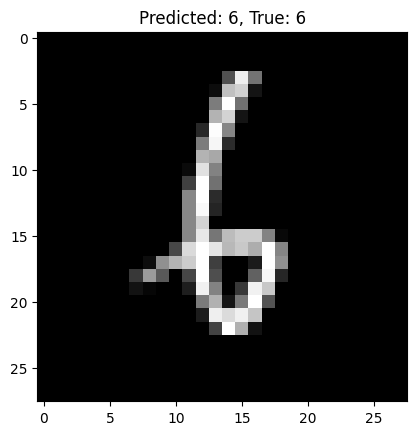

In [38]:
#Single example
random_idx = np.random.choice(len(X_test))
x_sample = X_test[random_idx]
y_true = np.argmax(y_test, axis=1)
y_sample_true = y_true[random_idx]
y_sample_pred_class = y_pred_classes[random_idx]

plt.title("Predicted: {}, True: {}".format(y_sample_pred_class, y_sample_true))
plt.imshow(x_sample.reshape(28,28), cmap='gray')


Confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

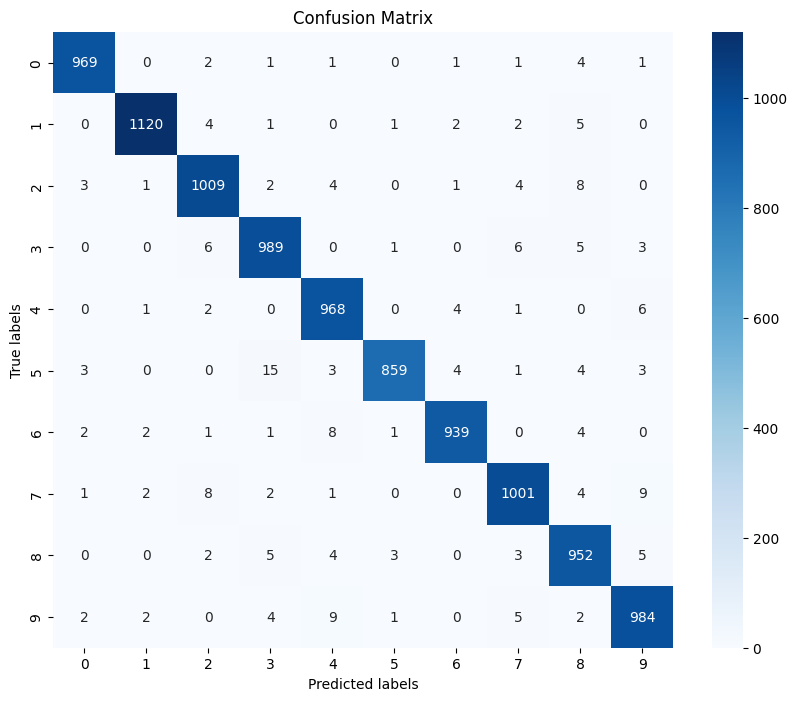

In [39]:
confusion_mtx = confusion_matrix(y_true, y_pred_classes)

fig, ax = plt.subplots(figsize=(10,8))
ax = sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues')
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

Misclassified examples

Now we investigate **which digits the model gets wrong** and **why**:
- Find the most confidently incorrect predictions
- Visualize challenging examples
- Understand model limitations and areas for improvement


In [40]:
errors = (y_pred_classes - y_true != 0)
y_pred_classes_errors = y_pred_classes[errors]
y_pred_errors = y_pred[errors]
y_true_errors = y_true[errors]
X_test_errors = X_test[errors]



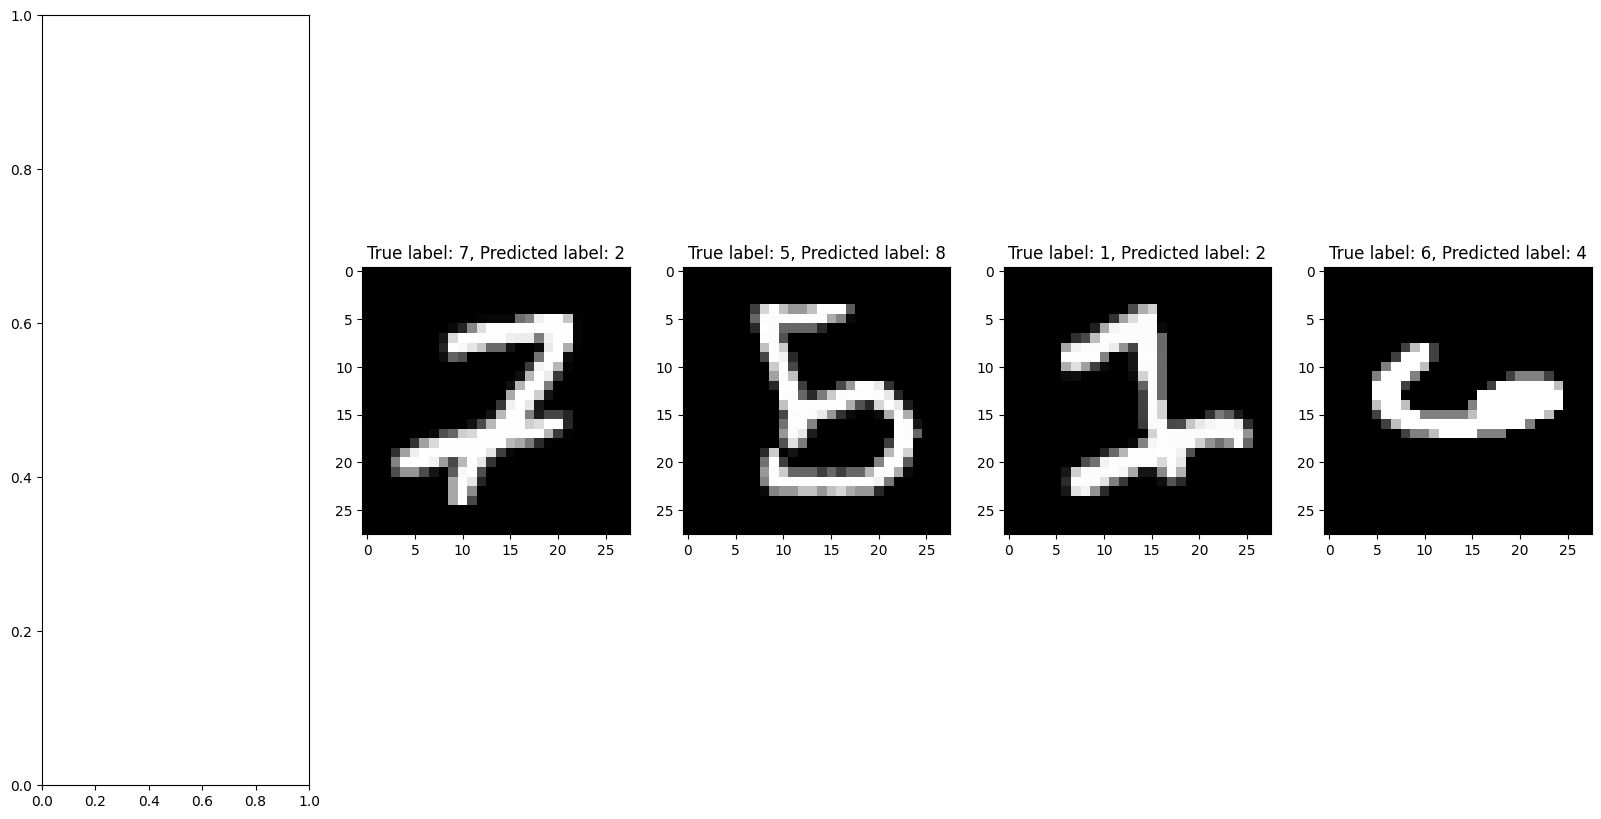

In [41]:
y_pred_errors_probability = np.max(y_pred[errors], axis=1)
true_probability = np.diagonal(np.take(y_pred_errors, y_true_errors, axis=1))
diff_errors_pred_true = y_pred_errors_probability - true_probability

#get list of indices of sorted differences
sorted_idx_diff_errors = np.argsort(diff_errors_pred_true)
top_idx_diff_errors = sorted_idx_diff_errors[-5:]

#show errors
num = len(top_idx_diff_errors)
f, ax = plt.subplots(1,num, figsize=(20,10))

for i in range(1,num):
    idx = top_idx_diff_errors[i]
    sample = X_test_errors[idx].reshape(28,28)
    y_t = y_true_errors[idx]
    y_p = y_pred_classes_errors[idx]
    ax[i].imshow(sample, cmap='gray')
    ax[i].set_title('True label: {}, Predicted label: {}'.format(y_t, y_p))

## 🎯 Results & Conclusions
- Achieved 0.97% accuracy on MNIST test set
- Model successfully learned to distinguish handwritten digits
- Error analysis revealed the most challenging digit pairs to classify